### **Day 2: Spark Architecture & The Cluster Components**

Yesterday, we learned that PySpark works by distributing data across a cluster of computers. Today, we will examine the actual mechanics of that cluster. We will break down the physical components, look at who gives the orders, who does the work, and exactly how your Python code communicates with a Java-based engine.

**Today's Objective**

By the end of this session, you will understand the Master-Worker topology of a Spark cluster, the distinct responsibilities of the Driver and Executor processes, and the exact sequence that occurs when PySpark translates your Python code into distributed execution.

**1. The Master-Worker Topology**

A Spark cluster does not operate as a loose collection of equal machines. It follows a strict **Master-Worker design pattern** (often referred to as a manager-worker relationship).

When you run a PySpark application, you are interacting with three core software processes running on your hardware:

1. **The Driver Program (The Master)**
2. **The Cluster Manager (The Coordinator)**
3. **The Executors (The Workers)**

Let’s break down the exact responsibilities of each component.

**2. The Driver Program**

The Driver is the heart of your PySpark application. It is the specific process where your main `Sript.py` or Jupyter Notebook runs. Think of the Driver as the **Central Command Center**.

*Key Responsibilities of the Driver:*

* **Maintaining the SparkSession:** It creates and maintains the entry point of your application (the object that lets your code talk to the cluster).
* **Code Parsing and Analysis:** It analyzes your Python code and translates it into a logical execution plan.
* **Creating the DAG (Directed Acyclic Graph):** It builds a step-by-step structural blueprint of your data operations.
* **Task Scheduling:** It breaks down the blueprint into small physical units of work called **Tasks** and determines which worker machines should execute them based on where the data is located.
* **Result Aggregation:** Once the workers finish processing, the Driver collects the final, downsized results (like a total count or a summary statistic) to show them to you.

> **Critical Expert Warning:** Because the Driver is responsible for collecting results, if you accidentally run a command that forces the workers to send terabytes of raw data back to the single Driver machine, the Driver will run out of memory and crash instantly.

**3. The Cluster Manager**

The Driver does not directly own the physical hardware of the worker machines. Instead, it talks to an external service called the **Cluster Manager**.

Think of the Cluster Manager as an outside contractor that allocates resources. The Driver tells the Cluster Manager: *"I need 5 machines, each with 4 CPU cores and 16 Gigabytes of RAM to run this job."* The Cluster Manager looks at the physical servers available, allocates them to your application, and steps back.

Spark can plug into several different Cluster Managers depending on where it is deployed:

* **Standalone:** Spark’s own built-in, basic resource manager (great for testing or simple private clusters).
* **Apache YARN:** The standard resource manager used in traditional enterprise Hadoop ecosystems.
* **Kubernetes:** The modern, cloud-native container orchestration tool used to dynamically scale Spark.

**4. The Worker Nodes and Executors**

A **Worker Node** is the physical machine (or virtual server) connected to the cluster network. Inside each Worker Node, Spark launches isolated JVM processes called **Executors**.

Executors are the muscle of the operation. They do not make decisions; they simply execute the instructions handed to them by the Driver.

*Key Responsibilities of an Executor:*

* **Executing Tasks:** It receives a task from the Driver, runs the computation on its local CPU cores, and reports the status back to the Driver.
* **In-Memory Storage:** It provides the physical RAM space to store and cache data partitions. If you tell Spark to hold a dataset in memory, it sits inside the allocated RAM of the Executors.

**5. The PySpark Pipeline: How Python Talks to the JVM**

As we noted on Day 1, the core Spark engine is written in Scala/Java, but you are writing Python. Let’s look at the exact mechanical sequence that occurs when you execute a line of PySpark code.

*Step 1: The Local Python Process*

When you launch a PySpark script, a standard Python process starts. This is where your code is read.

*Step 2: The Py4J Gateway*

The Python process immediately initializes a library called **Py4J**. Py4J opens a local network connection (a socket) and spins up a native **Java Virtual Machine (JVM)** right next to your Python process on the Driver machine.

*Step 3: Translating Code to Objects*

When you write a command like `df.filter()`, your Python process doesn't execute the filter. It passes the command across the Py4J bridge to the local JVM. The JVM creates corresponding Java objects that represent your data structure.

*Step 4: Distributed Serialization*

The Driver's JVM takes those Java objects, converts them into a serialized data stream, and sends them over the network to the JVMs running inside the remote **Executors**.

*Step 5: Worker-Side Execution*

The Executors execute the task inside their own JVMs. If your task requires pure Python execution (such as a custom Python function you wrote yourself), the Executor JVM will spin up a temporary Python worker process on that machine, pipe the data into Python, process it, and pull it back into Java.


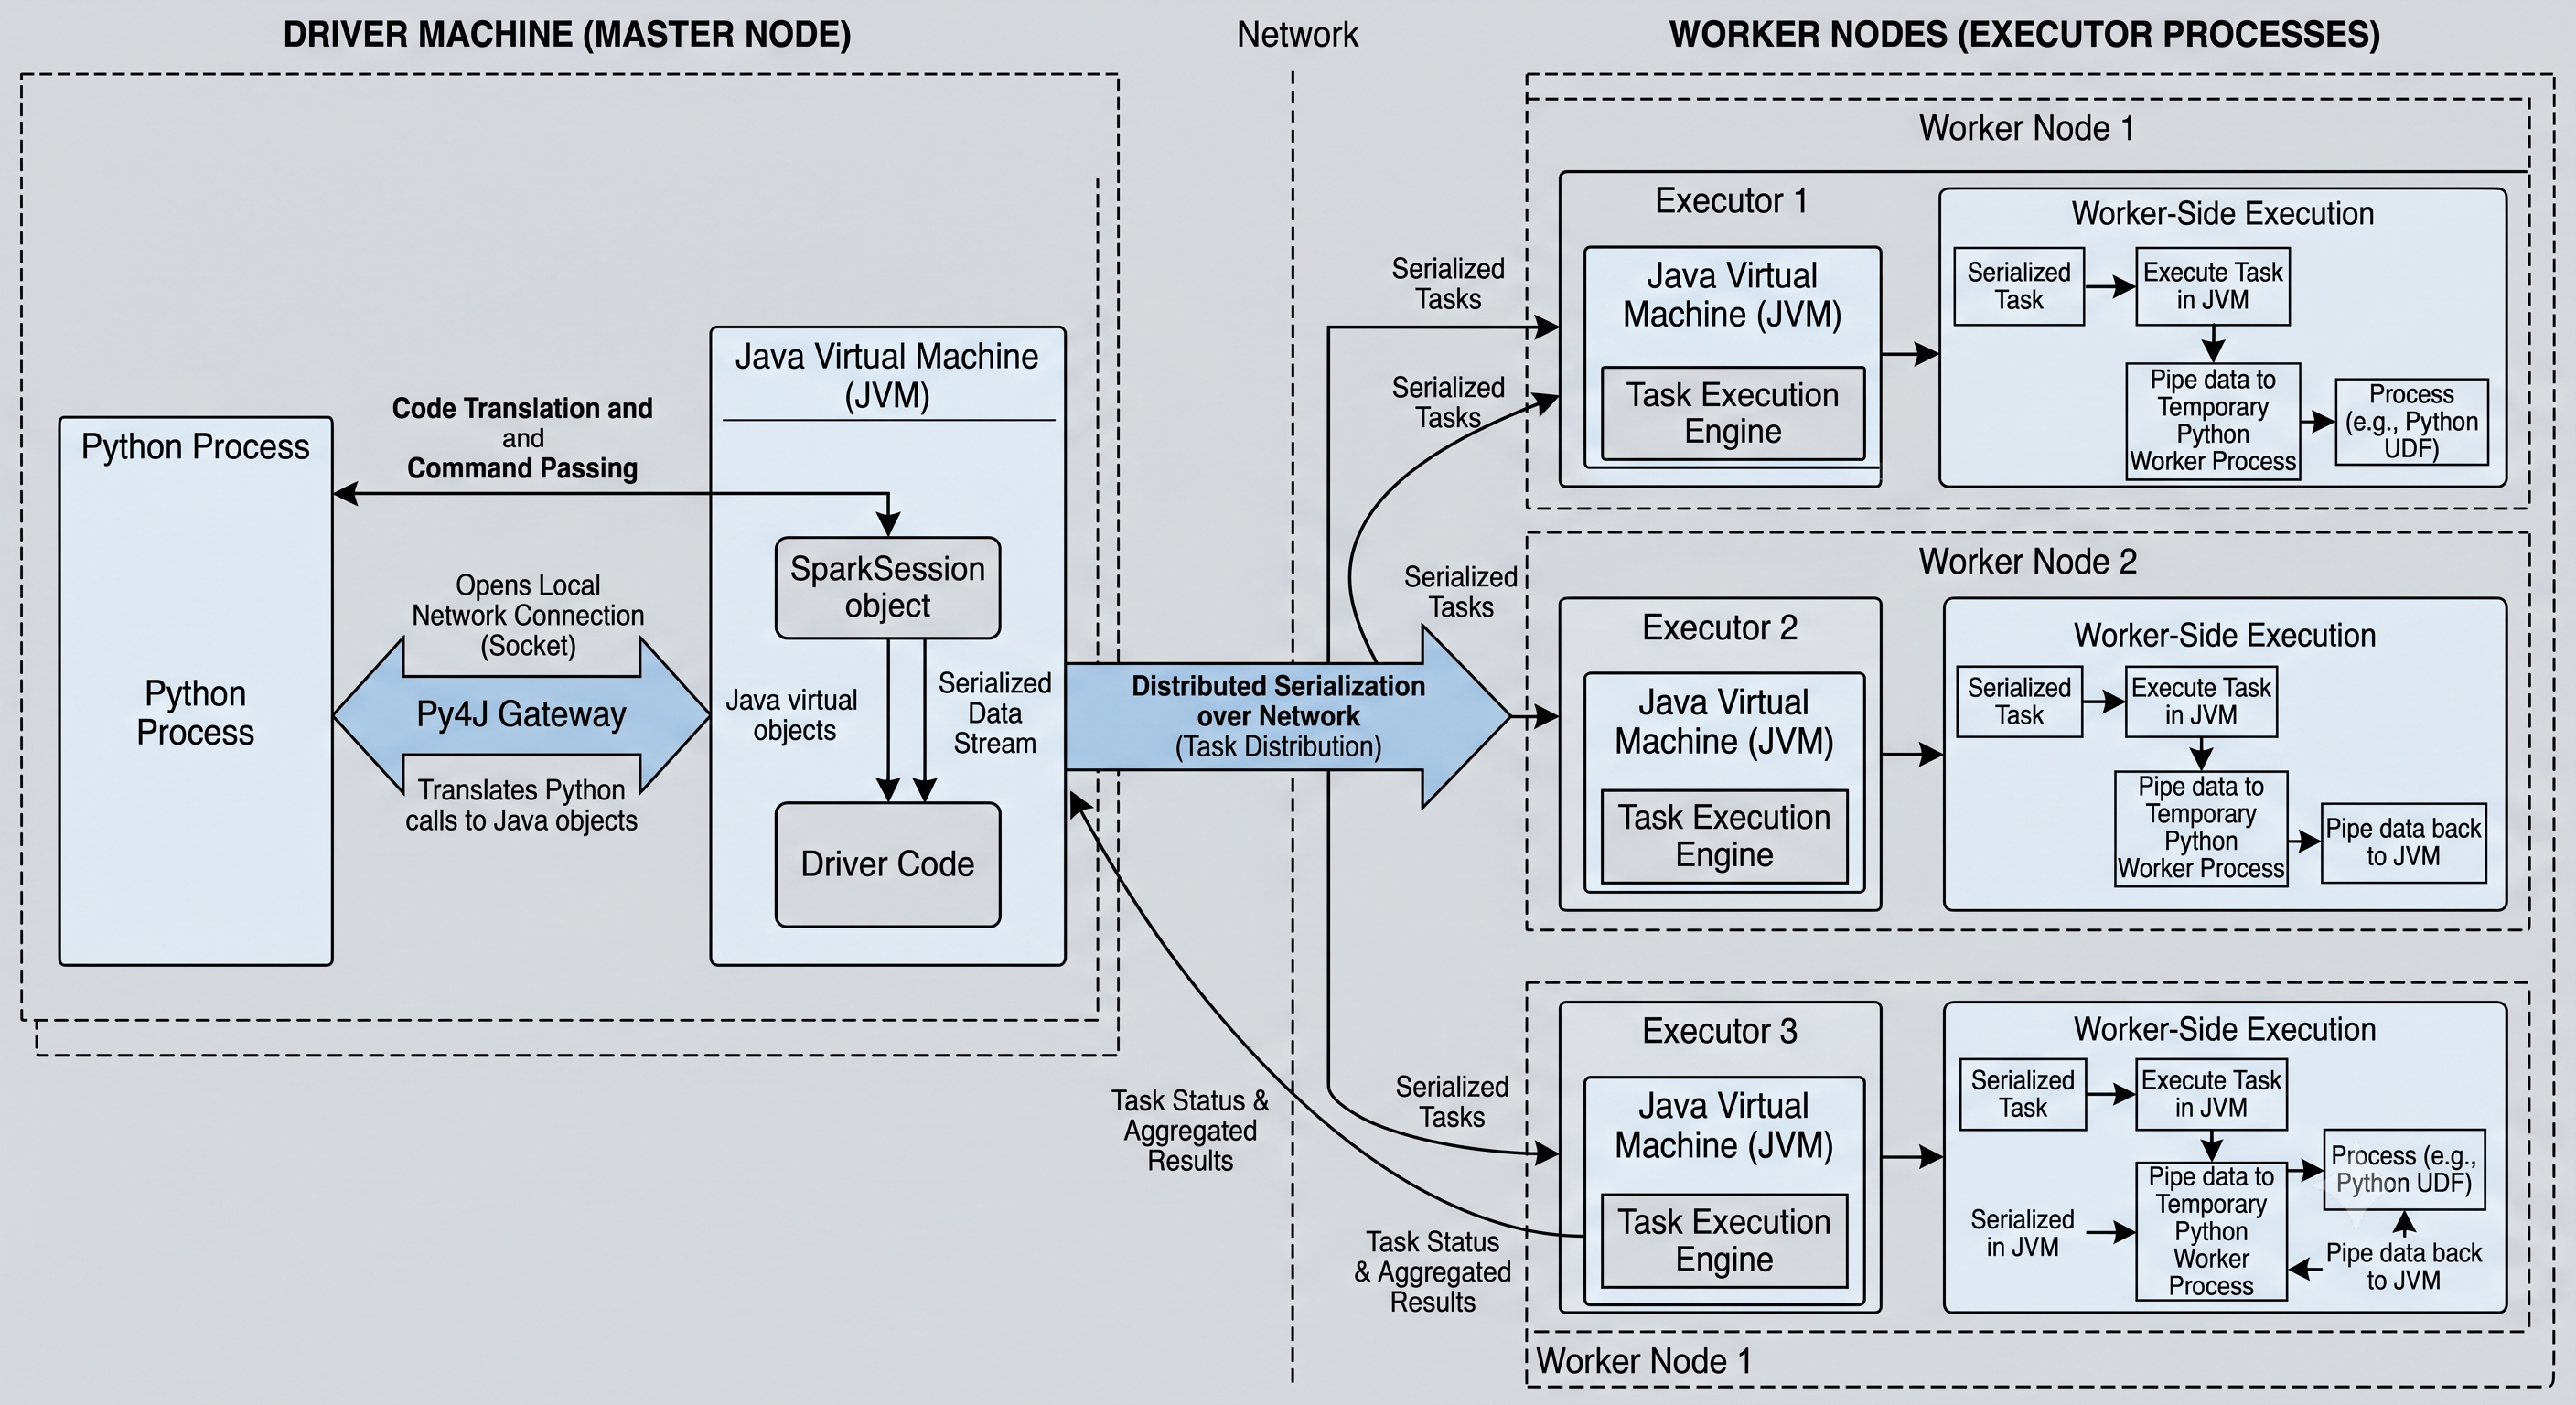